---
# **Análisis y Predicción de la Viralidad del Contenido de TikTok mediante Machine Learning** 

### Trabajo de Fin de Máster - Universidad de Madrid (UCM)

**Autora:** Rocío Pérez Holgado.

---
## **Estructura del Proyecto**

* **Cuaderno 1:** `01_Carga_y_Exploracion_Incial.ipynb`.
* **Cuaderno 2:** `02_Limpieza_y_Feature_Engineering.ipynb` **(Este cuaderno)**.

---
## **Introducción** 

---
## **Índice - Cuaderno 2:**
1. **Importación de Librerías**.
2. **Carga de los Datasets**.
3. **Limpieza y Preprocesamiento de los Datos**.
    * 3.1. Columnas Irrelevantes.
    * 3.2. Cambiar Tipología de Variables (dtypes).
    * 3.3. Datos Faltantes o Nulos.
    * 3.4. Valores atípicos (Outliers).
5. **Definición de la Variable Objetivo**.
6. **Unificación de los Datasets**.
7. **Ingeniería de Características (Feature Engineering)**.
8. **Comprobaciones Finales del Dataset**.
9. **Exportación del Dataset Preparado**.

---
## **1. Importación de Librerías**

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
## **2. Carga de los Datasets**

In [2]:
videos_df = pd.read_parquet("../datos/videos.parquet")
engagement_df = pd.read_parquet("../datos/engagement_daily.parquet")
creator_df = pd.read_parquet("../datos/creator_daily.parquet")

---
## **3. Limpieza y Preprocesamiento de los Datos**

#### **3.1. Columnas Irrelevantes**
---

Las columnas irrelevantes son aquellas que no aportan información útil para el análisis o predicción y, por tanto, se pueden eliminar del conjunto de datos para simplificar y reducir el dataset.

Las columnas irrelevantes pueden ser: 
* **Columnas que contienen información equivalente**, es decir, variables, que representan el mismo concepto mediante diferentes formatos.
* **Columnas con información redundante o duplicada**.
* **Columnas identificativas**, solo se usan para identificar registros y no contiene información predictiva.
* **Columnas que no aportan información relevante para el objetivo del estudio**, debido a que su contenido no tiene utilidad para el análisis.
* **Variables que pueden provocar fuga de información (data leakage)**, cuando contienen información que únicamente seria disponible despues del momento en el que se realiza la predicción.

In [3]:
videos_df = videos_df.drop(columns=["is_ads"], errors="ignore")

* Elimninado porque como vimos anteriormente era un valor constante.

Comprobar que se ha eliminado de forma correcta:

In [4]:
print("Columnas de videos:", videos_df.columns.tolist())

Columnas de videos: ['video_id', 'author_id', 'create_time', 'create_date', 'duration', 'ratio', 'desc_language', 'is_english', 'desc', 'sticker_text', 'hashtags', 'created_by_ai', 'music_selected_from', 'music_album', 'music_author', 'music_owner_id', 'music_id', 'music_title', 'transcript', 'word_count', 'emoji_count', 'question_count', 'hashtag_count', 'speaking_rate', 'gpt_summary', 'topic', 'anger', 'joy', 'surprise', 'sadness', 'disgust', 'fear']


In [5]:
creator_df = creator_df.drop(columns=["enterprise_verified"], errors="ignore")

* Elimninado porque todos sus registros eran nulo. 

Comprobar que se ha eliminado de formna correcta:

In [6]:
print("\nColumnas de creator:", creator_df.columns.tolist())


Columnas de creator: ['author_id', 'date', 'follower_count', 'following_count', 'total_favorited', 'video_count']


**Nota importante:** Las variables identificadoras (claves primarias) de las tablas no han sido eliminadas porque son necesarias para validar y unificar las tablas más adelante.

#### **3.2. Cambiar Tipología de Variables (dtypes)**
---

##### **Variable fecha/hora**

Variables fecha/hora que habia que cambiar a `datetime`:
* Tabla `videos`: `create_time` y `create_date`.
* Tabla `engagement`: `date`.
* Tabla `creator`: `date`.
* Todas ellas almacenadas como `str`.

In [7]:
videos_df["create_time"] = pd.to_datetime(
    videos_df["create_time"],
    errors="coerce"
)

In [8]:
videos_df["create_date"] = pd.to_datetime(
    videos_df["create_date"],
    errors="coerce"
)

Una vez pasadas a `datetime` (más seguro para la comparación), podemos comprobar si las dos variables son iguales para todos los registros:
* Si devuelve true, coinciden en todos los registros y por tanto, una de ellas se puede eliminar.

In [9]:
(videos_df["create_time"].dt.date == videos_df["create_date"].dt.date).all()

np.True_

* Elegimos eliminar `create_date` debido a que solo almacena la fecha mientras que `create_time` es un `TIMESTAMP`. Esto quiere decir que almacena una marca tiempo completa (hh:mm:sss).
* Por tanto, si necesitamos trabajar con la fecha podemos extraerla de `create_time`, al igual que cualquier tipo de dato relacionado con la marca de tiempo.
* Si eliminasemos, `create_time` estaríamos perdiendo información y no tendriamos forma de recuperarla.

In [10]:
videos_df = videos_df.drop(columns=["create_date"], errors="ignore")

Volvemos a convertir las variables en tipo `date`:

In [11]:
engagement_df["date"] = pd.to_datetime(
    engagement_df["date"],
    errors="coerce"
)

In [12]:
creator_df["date"] = pd.to_datetime(
    creator_df["date"],
    errors="coerce"
)

#### **3.3. Datos Faltantes o Nulos**
---

Existen varias formas de manejar los datos faltantes:
  1. **Eliminar filas con registros faltantes:**
        * Descartar las filas quer contienen datos nulos.
        * Ventajas:
            * Útil en conjunto de datos grandes.
        * Desventaja:
            * En conjuntos de datos pequeños, puede afectar a la calidad del modelo al reducir la cantidad de datos para el entrenamiento. 
  2. **Eliminar la columna:**
        * Eliminar toda la columna si una proporción significativa de sus valores es nula.
        * Ventajas:
            * Sencillo y fácil de aplicar.
        * Desventaja:
            * Eliminar una columna puede deteriorar la calidad del modelo si dicha columna contiene información importante. Antes de hacer esto, debemos evaluar la importancia de la columna.
  3. **Imputación simple:**
        * Para las variables categoricas:
            * Rellenar los valores faltantes con la categoría que aparece con mayor frecuencia (moda).
        * Para las variables cuantitativas:
            * Sustituir valores perdidos por la media o la continua.
            * Se usará la mediana si la distribución es asimétrica.
            * Se usará la media si la distribución es simétrica.
        * Ventaja:
            * No elimina filas ni columnas.
        * Desventaja:
            * Puede introducir sesgos que afecten a la calidad del modelo.
  5. **Imputación por modelos:**
     * Aplicar algoritmos de machine learning para predecir y reemplazar los valores faltantes en función de otros datos disponibles.
        * Ventaja:
            * Permite conservar la integridad del conjunto de daots y, si el modelo está bien diseño, puede reducir el sesgo.
        * Desventaja:
            * Requiere una cantidad suficiente de datos para entrenar el modelo. Además la calidad de la imputación depende de la precisión del modelo que será entrenado con esos datos. Por tanto, si no tenemos suficientes datos para entrenar bien al modelo, no haremos una buena imputación.
            * Proceso complejo.
 6. **Crear una nueva categoría para los datos faltantes:**
    * Si la presencia de valores pérdidos es muy grande, deberíamos crear una nueva categoría llamada "Desconocido" o "No disponible" para ellos.

In [13]:
columnas_recuento_videos = [
    "word_count",
    "emoji_count",
    "question_count",
    "hashtag_count"
]

videos_df[columnas_recuento_videos] = (
    videos_df[columnas_recuento_videos]
    .fillna(0)
    .astype("int64")
)

videos_df["speaking_rate"] = videos_df["speaking_rate"].fillna(0)

* Variables numéricas derivadas de texto o audio:
* Un valor nulo representa ausencia de texto, emojis, preguntas, hashtags o voz. Por ello se imputa con 0.

In [14]:
# hashtags contiene listas de objetos y no puede utilizarse directamente
# como variable predictora.

# Se conserva hashtag_count, que ya recoge el número de hashtags
# de cada vídeo.

videos_df = videos_df.drop(columns="hashtags")

In [15]:
columnas_emociones = [
    "anger",
    "joy",
    "surprise",
    "sadness",
    "disgust",
    "fear"
]

filas_antes = len(videos_df)

videos_df = videos_df.dropna(subset=columnas_emociones)

* Se eliminan los registros con valores nulos en alguna emoción.
* Debido a que como hemos visto antes solo representan aproximadamente el 0,47 % del dataset.

In [16]:
columnas_texto = [
    "desc",
    "sticker_text",
    "music_album",
    "music_author",
    "music_title",
    "transcript",
    "gpt_summary"
]

for columna in columnas_texto:
    videos_df[columna] = videos_df[columna].fillna("Sin información")

* Sustituido los valores nulos por la etiqueta `Sin informacion`.

In [17]:
videos_df["desc_language"] = videos_df["desc_language"].fillna("Desconocido")

videos_df["topic"] = videos_df["topic"].fillna("Desconocido")

videos_df["music_selected_from"] = (
    videos_df["music_selected_from"]
    .fillna("Desconocido")
)

videos_df["music_id"] = videos_df["music_id"].fillna("SIN_IDENTIFICAR")

videos_df["music_owner_id"] = (
    videos_df["music_owner_id"]
    .fillna("SIN_IDENTIFICAR")
)

* Variables categóricas e identificadores musicales sustituyen nulos por etiquetas. 

In [18]:
# Variables numéricas de creator_df:
# Representan el 0.07% de los registros totales, se pueden imputar directamente
columnas_recuento_creator = [
    "follower_count",
    "following_count",
    "video_count"
]

creator_df = creator_df.dropna(subset=columnas_recuento_creator)

In [19]:
# created_by_ai:
# Primero se rellena su único valor nulo con 0.
# Después se convierte de float64 a int64.

videos_df["created_by_ai"] = videos_df["created_by_ai"].fillna(0)

videos_df["created_by_ai"] = videos_df["created_by_ai"].astype("int64")

In [20]:
# Comprobación final de valores nulos.

print("Valores nulos en videos:")
display(videos_df.isnull().sum().sort_values(ascending=False))

print("Valores nulos en engagement:")
display(engagement_df.isnull().sum().sort_values(ascending=False))

print("Valores nulos en creator:")
display(creator_df.isnull().sum().sort_values(ascending=False))

Valores nulos en videos:


video_id               0
author_id              0
disgust                0
sadness                0
surprise               0
joy                    0
anger                  0
topic                  0
gpt_summary            0
speaking_rate          0
hashtag_count          0
question_count         0
emoji_count            0
word_count             0
transcript             0
music_title            0
music_id               0
music_owner_id         0
music_author           0
music_album            0
music_selected_from    0
created_by_ai          0
sticker_text           0
desc                   0
is_english             0
desc_language          0
ratio                  0
duration               0
create_time            0
fear                   0
dtype: int64

Valores nulos en engagement:


video_id                0
date                    0
days_since_post         0
play_count              0
like_count              0
comment_count           0
share_count             0
collect_count           0
download_count          0
whatsapp_share_count    0
dtype: int64

Valores nulos en creator:


author_id          0
date               0
follower_count     0
following_count    0
total_favorited    0
video_count        0
dtype: int64

#### **3.4. Valores atípicos (Outliers)**
---

En esta sección se emplean diagramas de caja (boxplots) para visualizar la distribución de las variables numéricas e identificar posibles valores atípicos. Estos gráficos permiten observar la mediana, el rango intercuartílico y los valores extremos de cada variable.

In [21]:
# Variables numéricas que se analizarán en cada dataset.

columnas_videos_outliers = [
    "duration",
    "speaking_rate",
    "word_count",
    "emoji_count",
    "question_count",
    "hashtag_count"
]

columnas_engagement_outliers = [
    "days_since_post",
    "play_count",
    "like_count",
    "comment_count",
    "share_count",
    "collect_count",
    "download_count",
    "whatsapp_share_count"
]

columnas_creator_outliers = [
    "follower_count",
    "following_count",
    "total_favorited",
    "video_count"
]

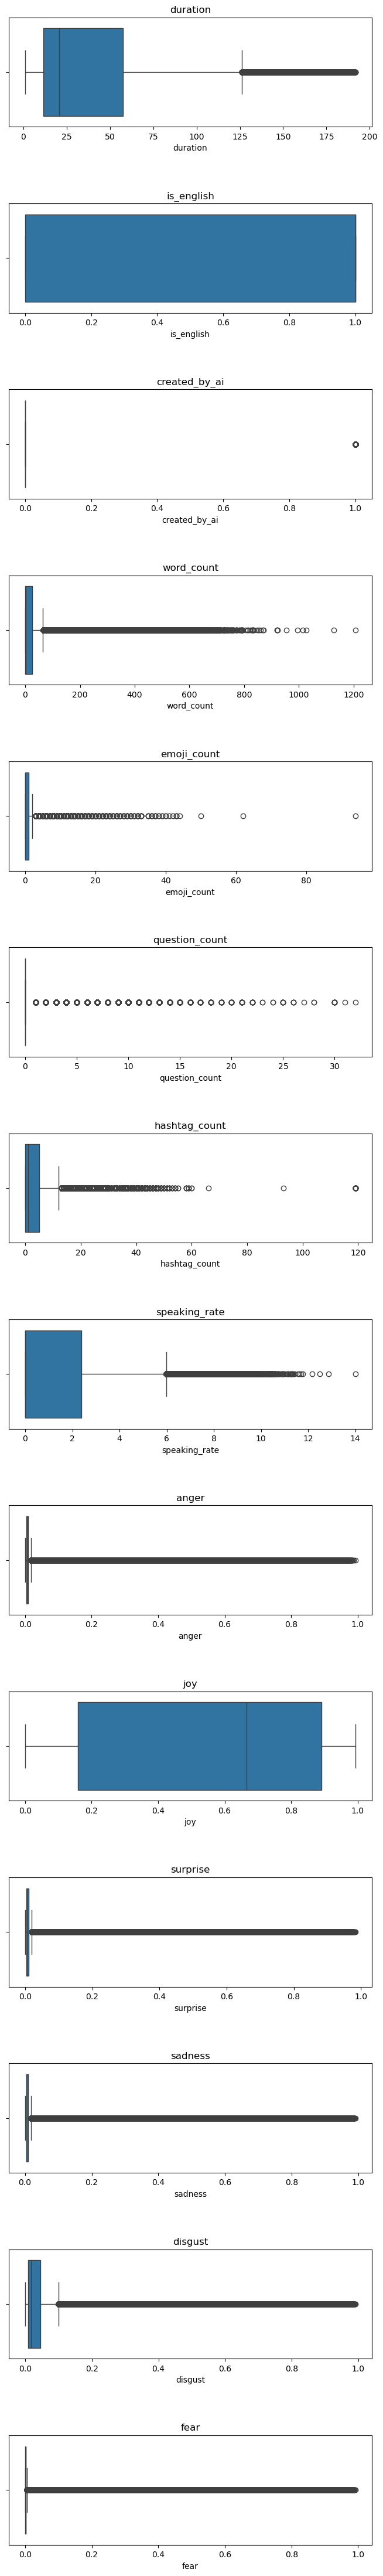

In [22]:
# Variables numéricas de videos

numericas_df = videos_df.select_dtypes(include=[np.number])

numericas_columnas = numericas_df.columns.values

fig, ax = plt.subplots(
    nrows=len(numericas_columnas),
    ncols=1,
    figsize=(8, 4 * len(numericas_columnas))
)

fig.subplots_adjust(hspace=0.7)

for i, col in enumerate(numericas_columnas):
    
    sns.boxplot(
        x=videos_df[col],
        ax=ax[i]
    )
    
    ax[i].set_title(col)

plt.show()

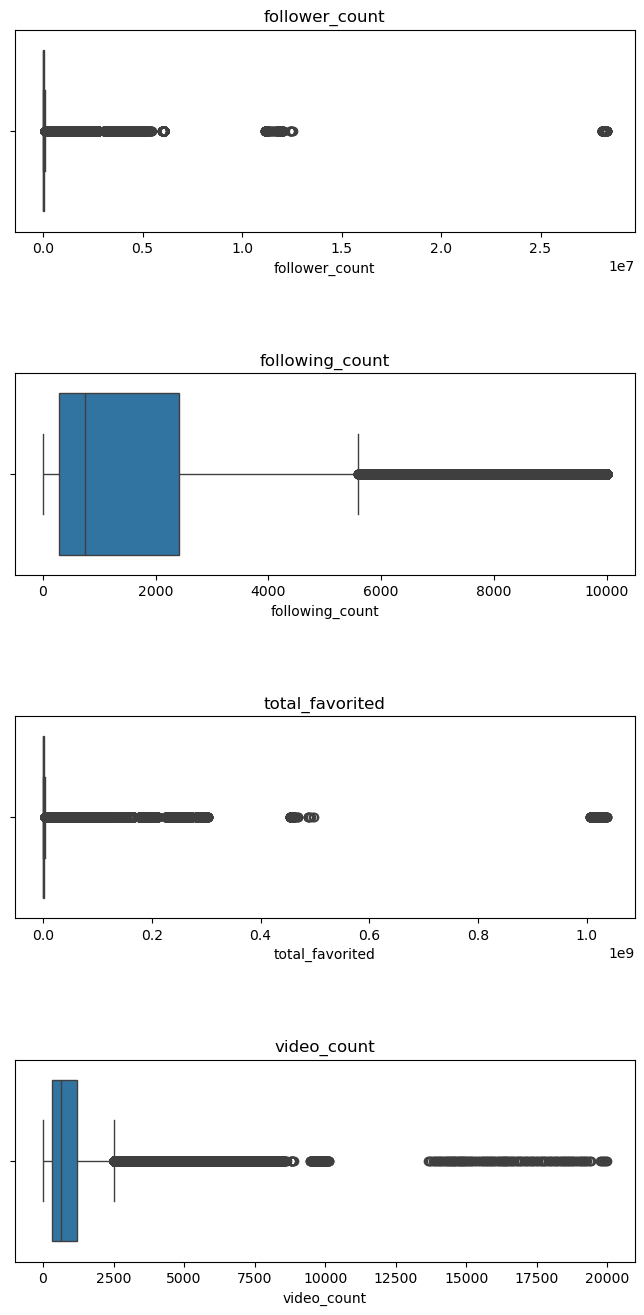

In [23]:
# Variables numéricas de creator

numericas_df = creator_df.select_dtypes(include=[np.number])

numericas_columnas = numericas_df.columns.values

fig, ax = plt.subplots(
    nrows=len(numericas_columnas),
    ncols=1,
    figsize=(8, 4 * len(numericas_columnas))
)

fig.subplots_adjust(hspace=0.7)

for i, col in enumerate(numericas_columnas):
    
    sns.boxplot(
        x=creator_df[col],
        ax=ax[i]
    )
    
    ax[i].set_title(col)

plt.show()

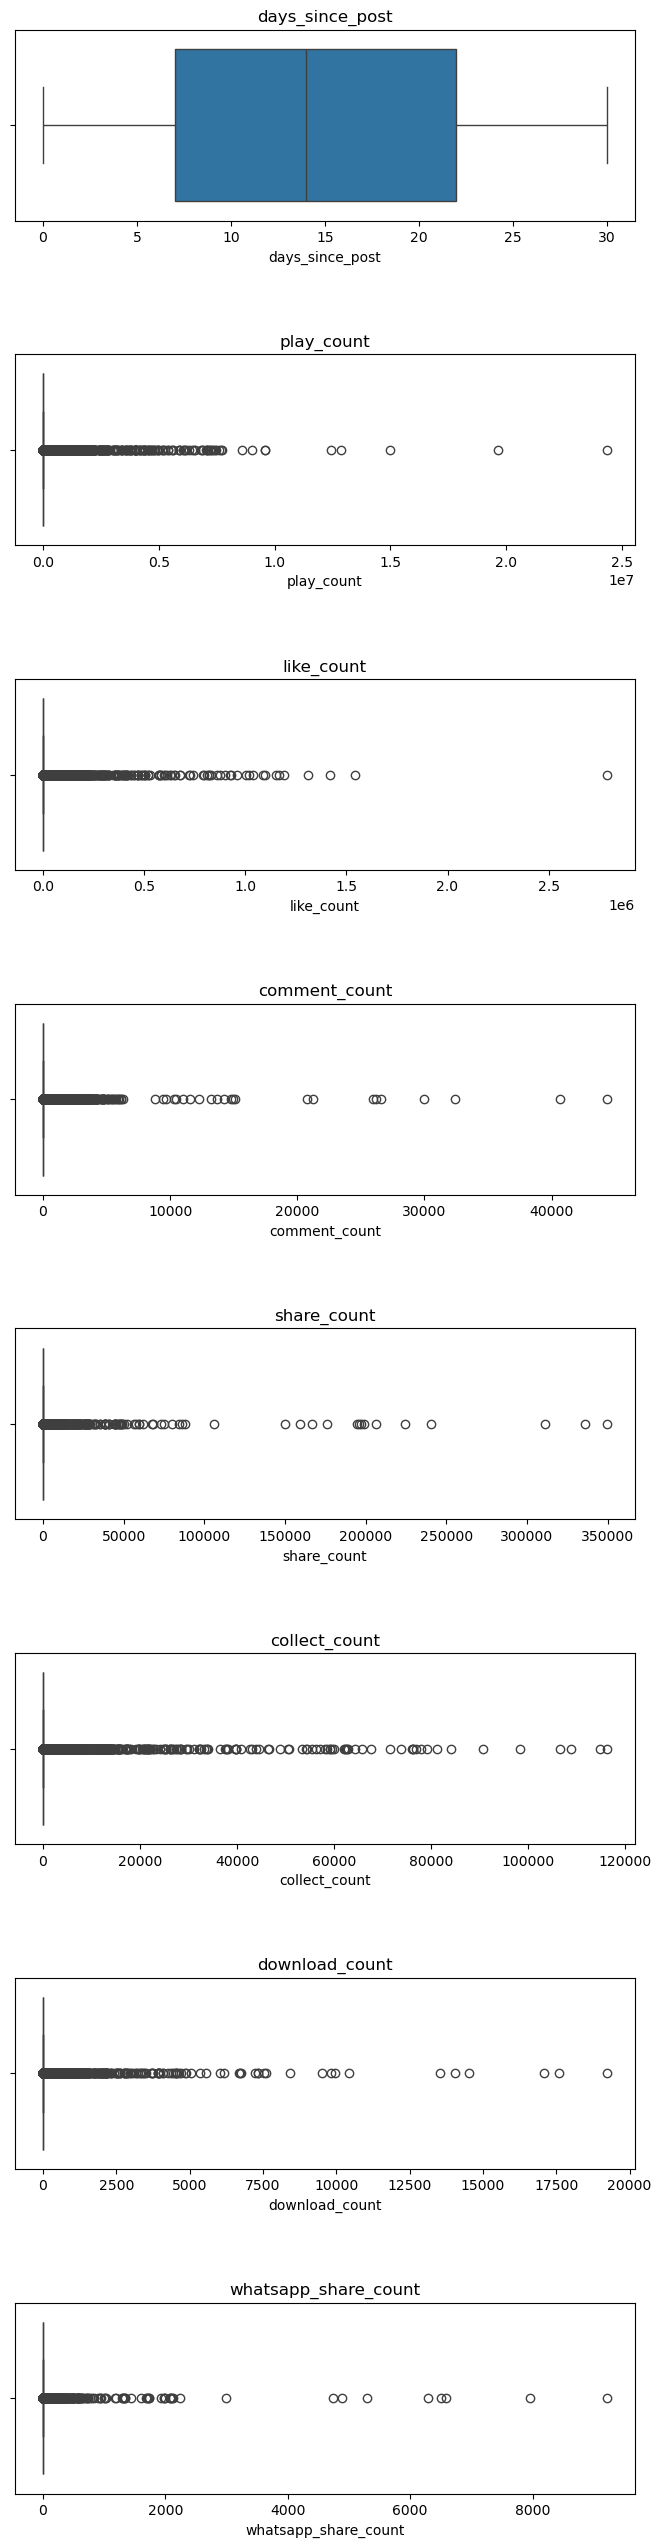

In [24]:
# Tiene más de seis millones de filas, usa una muestra para que el gráfico no tarde demasiado:
# Muestra aleatoria de 100.000 registros para visualizar engagement

engagement_muestra = engagement_df.sample(
    n=100_000,
    random_state=42
)

numericas_df = engagement_muestra.select_dtypes(include=[np.number])

numericas_columnas = numericas_df.columns.values

fig, ax = plt.subplots(
    nrows=len(numericas_columnas),
    ncols=1,
    figsize=(8, 4 * len(numericas_columnas))
)

fig.subplots_adjust(hspace=0.7)

for i, col in enumerate(numericas_columnas):
    
    sns.boxplot(
        x=engagement_muestra[col],
        ax=ax[i]
    )
    
    ax[i].set_title(col)

plt.show()

Tras la revisión gráfica, no se eliminan valores atípicos, ya que no se han identificado valores imposibles o errores de registro. Los valores extremos forman parte de la variabilidad natural de TikTok y son especialmente relevantes para el análisis de viralidad.

In [25]:
## Las emociones deben de estar entre 0 y 1
columnas_emociones = [
    "anger",
    "joy",
    "surprise",
    "sadness",
    "disgust",
    "fear"
]

valores_emociones_invalidos = (
    (videos_df[columnas_emociones] < 0) |
    (videos_df[columnas_emociones] > 1)
).sum()

display(valores_emociones_invalidos)

anger       0
joy         0
surprise    0
sadness     0
disgust     0
fear        0
dtype: int64

In [26]:
# Las variables de recuento no pueden ser negativas.

print("Valores negativos en engagement:")
display((engagement_df[columnas_engagement_outliers] < 0).sum())

print("Valores negativos en creator:")
display((creator_df[columnas_creator_outliers] < 0).sum())

print("Valores negativos en videos:")
display((videos_df[columnas_videos_outliers] < 0).sum())

Valores negativos en engagement:


days_since_post         0
play_count              0
like_count              0
comment_count           0
share_count             0
collect_count           0
download_count          0
whatsapp_share_count    0
dtype: int64

Valores negativos en creator:


follower_count     0
following_count    0
total_favorited    0
video_count        0
dtype: int64

Valores negativos en videos:


duration          0
speaking_rate     0
word_count        0
emoji_count       0
question_count    0
hashtag_count     0
dtype: int64

#### **3.5. Agrupación de Categorías**
---

In [27]:
# Se agrupan las resoluciones con presencia residual:
# 360p, 480p y 1080p pasan a la categoría "Otros".
# 540p y 720p se mantienen por tener mayor representación.

videos_df["ratio_agrupado"] = videos_df["ratio"]

videos_df.loc[
    ~videos_df["ratio"].isin(["540p", "720p", "Desconocido"]),
    "ratio_agrupado"
] = "Otros"

In [28]:
# Comprobación de la nueva distribución

videos_df["ratio_agrupado"].value_counts(dropna=False)

videos_df["ratio_agrupado"].value_counts(
    normalize=True,
    dropna=False
) * 100

ratio_agrupado
540p     92.713063
720p      6.826169
Otros     0.460768
Name: proportion, dtype: float64

In [29]:
#Una vez comprobado que está correcto, elimina la columna original:
videos_df = videos_df.drop(columns="ratio")

---
## **4. Definición de la Variable Objetivo**

La viralidad se define a partir del número de visualizaciones acumuladas a los 30 días desde la publicación del vídeo. Se considera viral aquel contenido cuyo valor de `play_count` se sitúa en el percentil 90 o superior de la distribución. Esta definición permite comparar todos los vídeos en el mismo horizonte temporal y obtener una variable objetivo binaria para un problema de clasificación.

In [30]:
# Primero comprobamos que existen observaciones a los 30 días
engagement_df["days_since_post"].value_counts().sort_index()

days_since_post
0     157065
1     206222
2     206193
3     206041
4     206012
5     206023
6     206052
7     206216
8     206227
9     206327
10    206030
11    205982
12    205937
13    206242
14    209543
15    205054
16    203386
17    201716
18    199919
19    198493
20    196937
21    195654
22    194117
23    193704
24    193197
25    193274
26    193021
27    193301
28    193465
29    193665
30     73940
Name: count, dtype: int64

In [31]:
# Se selecciona la métrica de cada vídeo cuando han pasado 30 días.

engagement_30_dias = engagement_df[
    engagement_df["days_since_post"] == 30
].copy()

print("Número de registros a los 30 días:", len(engagement_30_dias))

print(
    "Vídeos duplicados a los 30 días:",
    engagement_30_dias["video_id"].duplicated().sum()
)

Número de registros a los 30 días: 73940
Vídeos duplicados a los 30 días: 0


In [32]:
# Se calcula el percentil 90 de reproducciones.

umbral_viralidad = engagement_30_dias["play_count"].quantile(0.90)

print(f"Umbral de viralidad: {umbral_viralidad:,.0f} reproducciones")

Umbral de viralidad: 21,598 reproducciones


In [33]:
# Se crea la variable objetivo:
# 1 = vídeo viral
# 0 = vídeo no viral

engagement_30_dias["viral"] = 0

engagement_30_dias.loc[
    engagement_30_dias["play_count"] >= umbral_viralidad,
    "viral"
] = 1

engagement_30_dias["viral"] = (
    engagement_30_dias["viral"]
    .astype("int64")
)

In [34]:
# Comprobación de la distribución de la variable objetivo.

engagement_30_dias["viral"].value_counts()

engagement_30_dias["viral"].value_counts(normalize=True) * 100

viral
0    90.0
1    10.0
Name: proportion, dtype: float64

La variable objetivo presenta una distribución del 90 % de vídeos no virales y del 10 % de vídeos virales. Este resultado es coherente con la definición adoptada, basada en el percentil 90 de `play_count` a los 30 días. Aunque existe desequilibrio entre las clases, la proporción de casos virales es suficiente para entrenar un modelo de clasificación. El posible desequilibrio se abordará posteriormente durante la fase de modelado, sin modificar la distribución original del dataset.

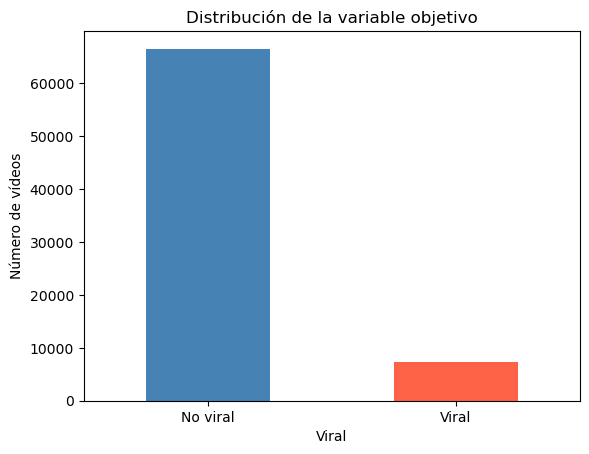

In [35]:
engagement_30_dias["viral"].value_counts().plot(
    kind="bar",
    color=["steelblue", "tomato"]
)

plt.title("Distribución de la variable objetivo")
plt.xlabel("Viral")
plt.ylabel("Número de vídeos")

plt.xticks([0, 1], ["No viral", "Viral"], rotation=0)

plt.show()

---
## **5. Unificación de los Datasets**

## 5. Unificación de los Datasets

Una vez completado el proceso de limpieza y preprocesamiento de los tres datasets, se procede a integrar la información en un único conjunto de datos preparado para las siguientes fases del análisis y modelado.

La tabla principal será `videos_df`, ya que cada registro representa un vídeo único. Sobre esta tabla se incorporarán, por un lado, la variable objetivo de viralidad obtenida a partir de `engagement_df` y, por otro, las métricas correspondientes a cada creador procedentes de `creator_df`.

La unión con el dataset de engagement se realiza mediante la variable `video_id`. Únicamente se incorpora la etiqueta `viral`, calculada a partir de las visualizaciones acumuladas a los 30 días desde la publicación. Las demás métricas de engagement no se incluyen como variables predictoras, puesto que contienen información posterior a la publicación del vídeo y podrían provocar fuga de información.

La unión con `creator_df` se realiza mediante `author_id` y la fecha de referencia anterior a la publicación del vídeo. De este modo, se emplea exclusivamente información que estaría disponible antes de que el vídeo comenzara a recibir interacciones, evitando incorporar datos futuros del creador.

Como resultado, se obtiene `dataset_unificado`, donde cada fila representa un vídeo e incluye sus características, el estado previo del creador y la variable objetivo `viral`.

In [36]:
# Dataset que contiene únicamente la variable objetivo.
# No conservamos play_count porque se ha utilizado para crear viral.

objetivo_df = engagement_30_dias[
    ["video_id", "viral"]
].copy()

In [37]:
# Comprobación de que cada vídeo tiene una única etiqueta.

objetivo_df["video_id"].duplicated().sum()

np.int64(0)

In [38]:
# Se asegura que las claves tengan el mismo tipo de dato.

videos_df["video_id"] = videos_df["video_id"].astype("string")

objetivo_df["video_id"] = objetivo_df["video_id"].astype("string")

videos_df["author_id"] = videos_df["author_id"].astype("string")

creator_df["author_id"] = creator_df["author_id"].astype("string")

In [39]:
# Unión de videos con la variable objetivo.

filas_antes = len(videos_df)

dataset_unificado = videos_df.merge(
    objetivo_df,
    on="video_id",
    how="inner",
    validate="one_to_one"
)

print("Vídeos antes de unir la variable objetivo:", filas_antes)
print("Vídeos con variable objetivo:", len(dataset_unificado))
print("Vídeos descartados:", filas_antes - len(dataset_unificado))

Vídeos antes de unir la variable objetivo: 208565
Vídeos con variable objetivo: 73623
Vídeos descartados: 134942


In [40]:
# Se crea la fecha de referencia para unir los datos del creador.
# Se utiliza el día anterior a la publicación para evitar fuga de información.

dataset_unificado["fecha_referencia_creador"] = (
    dataset_unificado["create_time"].dt.normalize()
    - pd.Timedelta(days=1)
)

In [41]:
# Se cambia el nombre de date para poder unirlo con fecha_referencia_creador.

creator_para_unir = creator_df.rename(
    columns={"date": "fecha_referencia_creador"}
)

In [42]:
# Unión con las métricas diarias del creador.

dataset_unificado = dataset_unificado.merge(
    creator_para_unir,
    on=["author_id", "fecha_referencia_creador"],
    how="left",
    validate="many_to_one"
)

In [43]:
# Comprobación de la unión con creator_df.

porcentaje_creadores_unidos = (
    dataset_unificado["follower_count"].notna().mean() * 100
)

print(
    f"Porcentaje de vídeos con información del creador: "
    f"{porcentaje_creadores_unidos:.2f}%"
)

Porcentaje de vídeos con información del creador: 98.01%


In [44]:
# La fecha de referencia solo se ha usado para unir los datasets,
# por lo que puede eliminarse.

dataset_unificado = dataset_unificado.drop(
    columns="fecha_referencia_creador"
)

In [45]:
# Comprobación final del dataset unificado.

print("Dimensiones finales:", dataset_unificado.shape)

print("\nDistribución de la variable objetivo:")
display(dataset_unificado["viral"].value_counts())

display(dataset_unificado.head())

Dimensiones finales: (73623, 35)

Distribución de la variable objetivo:


viral
0    66234
1     7389
Name: count, dtype: int64

,video_id,author_id,create_time,duration,desc_language,is_english,desc,sticker_text,created_by_ai,music_selected_from,...,surprise,sadness,disgust,fear,ratio_agrupado,viral,follower_count,following_count,total_favorited,video_count
0,7386493327656504607,6958316329012003846,2024-06-30 21:46:54,20.067,un,0,#fallowme #foryoupage #fyp #fypp #goodengery #...,Sin información,0,edit_page_list,...,0.004642,0.011638,0.154876,0.001623,540p,0,2549.0,4782.0,3527.0,532.0
1,7384586135160261919,6825348786513626118,2024-06-25 18:25:55,10.449,en,1,Fable being the center of attention #catsoftik...,Sin información,0,shoot_page_search,...,0.003632,0.002551,0.010292,0.000383,540p,0,NaN,NaN,NaN,NaN
2,7386800802024754475,6822338188011865093,2024-07-01 17:39:53,45.467,en,1,This is IT 😂 I love y’all baaaad 🫶🏾❤️ Click th...,SHIRTS RESTOCKED‼️💕🚛,0,original,...,0.013656,0.004607,0.004065,0.000539,540p,0,20422.0,338.0,1034735.0,550.0
3,7386474017143754027,6792726896200139777,2024-06-30 20:31:47,66.467,en,1,Our Yard,Sin información,0,video_capsule_recommend,...,0.002883,0.007441,0.008705,0.000671,540p,0,3714.0,476.0,93735.0,2189.0
4,7386146638676397355,6792726896200139777,2024-06-29 23:21:40,14.793,un,0,#onthisday,Sin información,0,original,...,0.005094,0.007011,0.079359,0.000801,540p,0,3714.0,476.0,93730.0,2188.0


In [48]:
dataset_unificado.shape

(73623, 35)

In [46]:
dataset_unificado.columns.tolist()

['video_id',
 'author_id',
 'create_time',
 'duration',
 'desc_language',
 'is_english',
 'desc',
 'sticker_text',
 'created_by_ai',
 'music_selected_from',
 'music_album',
 'music_author',
 'music_owner_id',
 'music_id',
 'music_title',
 'transcript',
 'word_count',
 'emoji_count',
 'question_count',
 'hashtag_count',
 'speaking_rate',
 'gpt_summary',
 'topic',
 'anger',
 'joy',
 'surprise',
 'sadness',
 'disgust',
 'fear',
 'ratio_agrupado',
 'viral',
 'follower_count',
 'following_count',
 'total_favorited',
 'video_count']

---
## **6. Comprobaciones Finales del Dataset**

---
## **7. Exportación del Dataset Preparado**